# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Social Media And Mental Health Impact Dataset](https://www.kaggle.com/datasets/shivasingh4945/student-social-media-and-mental-health-impact)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## last Five row

In [4]:
df.tail()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7
4999,19,Male,China,Undergraduate,WeChat,Entertainment,5.4,177,1.2,1.5,6.3,High,6.1


## Shape of our dataset

In [5]:
df.shape

(5000, 13)

## List out all columns

In [6]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Age                          int64
Gender                      object
Country                     object
Academic_Level              object
Most_Used_Platform          object
Purpose_Of_Use              object
Avg_Daily_Usage_Hours      float64
Daily_Unlocks                int64
Study_Hours                float64
Physical_Activity_Hours    float64
Sleep_Hours_Per_Night      float64
Stress_Level                object
Mental_Health_Score        float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(2)

## Summary

In [11]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

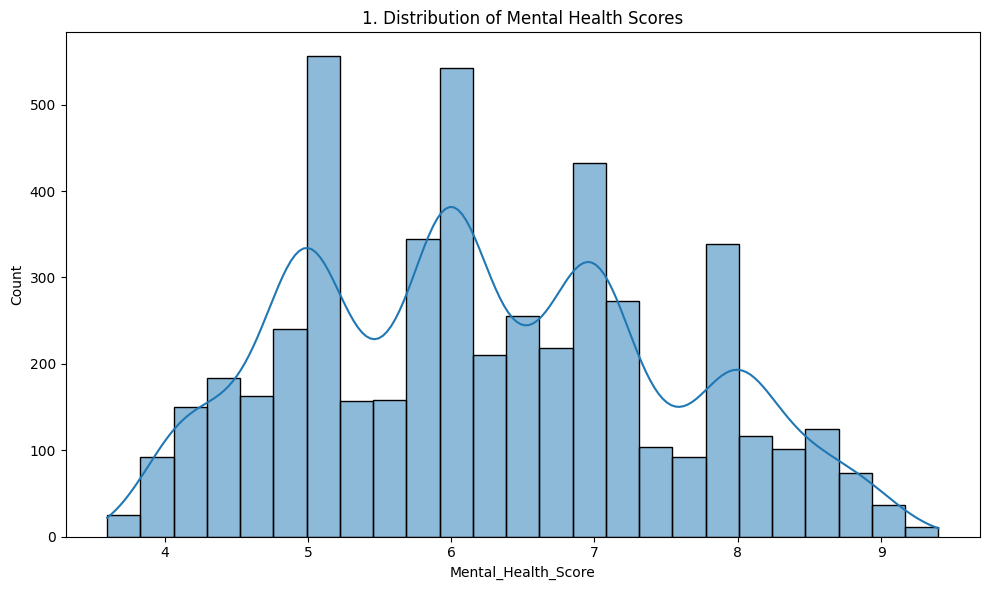

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Mental_Health_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Mental Health Scores')
show_fig()
plot_no += 1

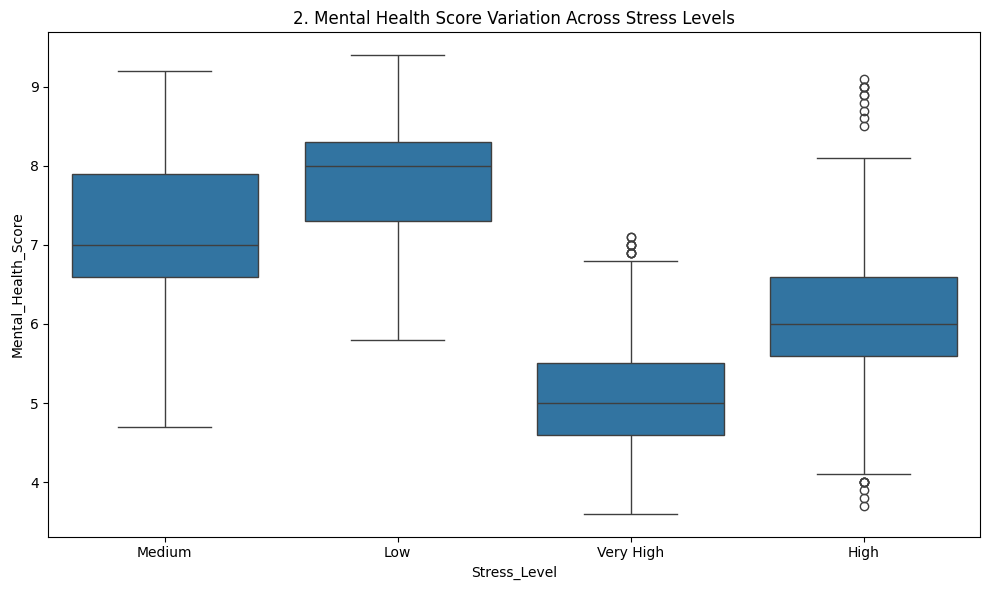

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stress_Level', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health Score Variation Across Stress Levels')
show_fig()
plot_no += 1

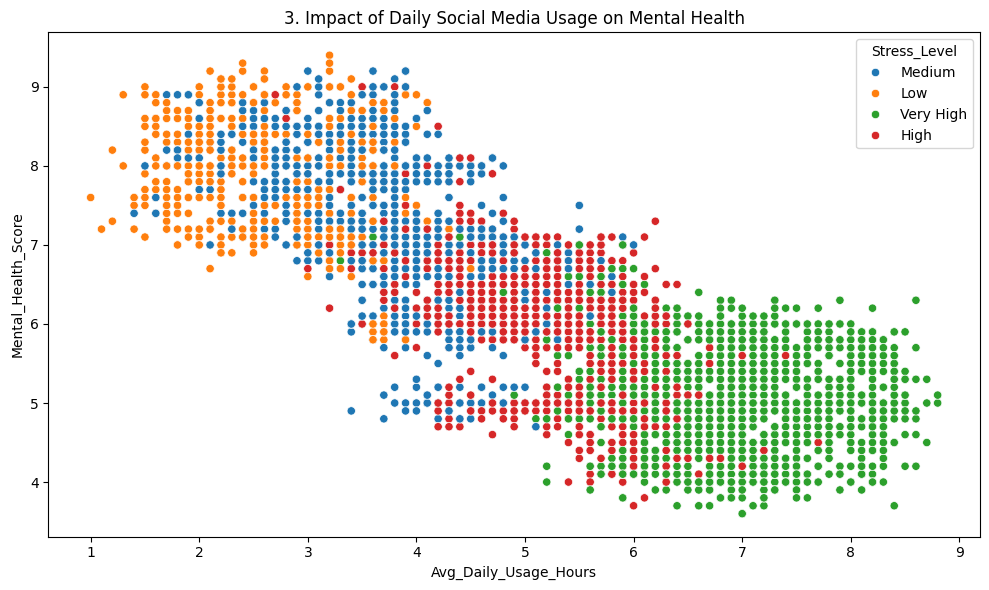

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', hue='Stress_Level')
plt.title(f'{plot_no}. Impact of Daily Social Media Usage on Mental Health')
show_fig()
plot_no += 1

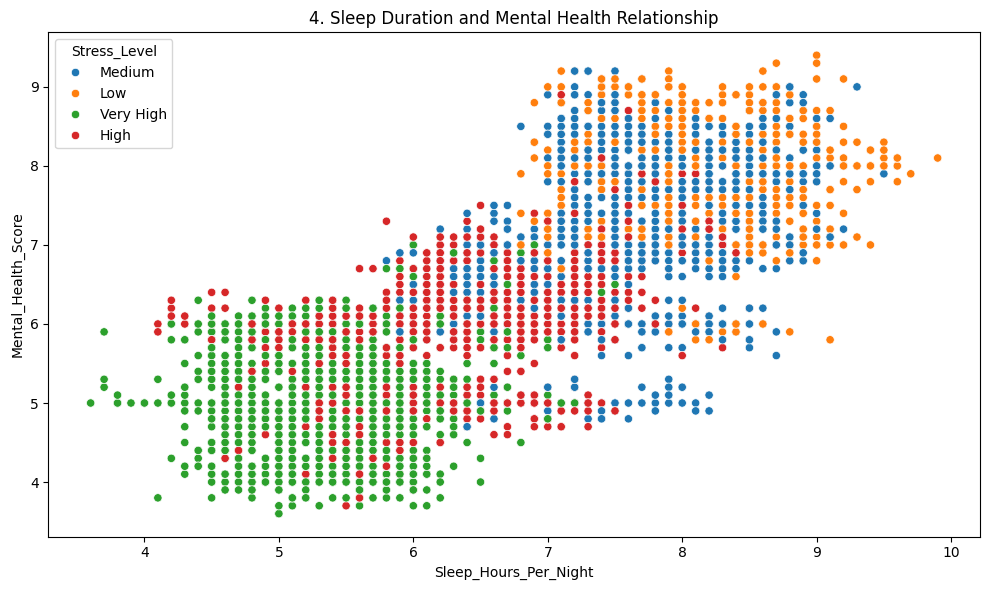

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sleep_Hours_Per_Night', y='Mental_Health_Score', hue='Stress_Level')
plt.title(f'{plot_no}. Sleep Duration and Mental Health Relationship')
show_fig()
plot_no += 1

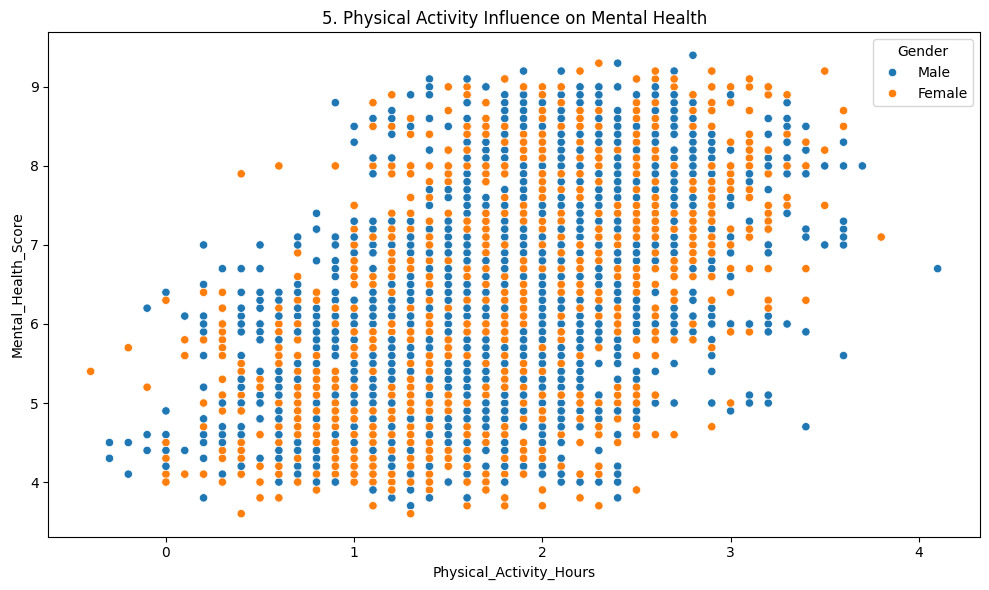

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Physical_Activity_Hours', y='Mental_Health_Score', hue='Gender')
plt.title(f'{plot_no}. Physical Activity Influence on Mental Health')
show_fig()
plot_no += 1

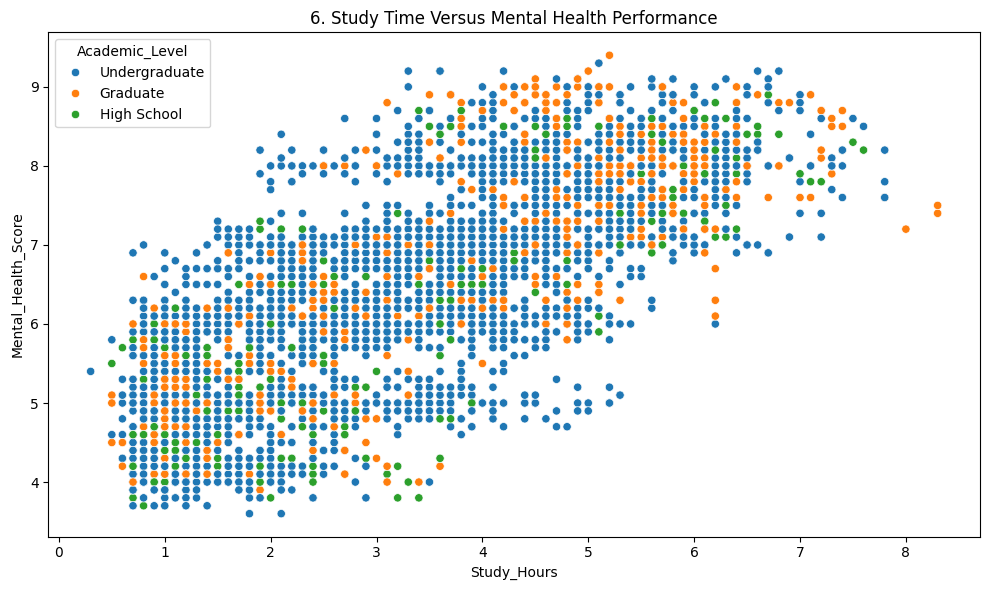

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Study_Hours', y='Mental_Health_Score', hue='Academic_Level')
plt.title(f'{plot_no}. Study Time Versus Mental Health Performance')
show_fig()
plot_no += 1

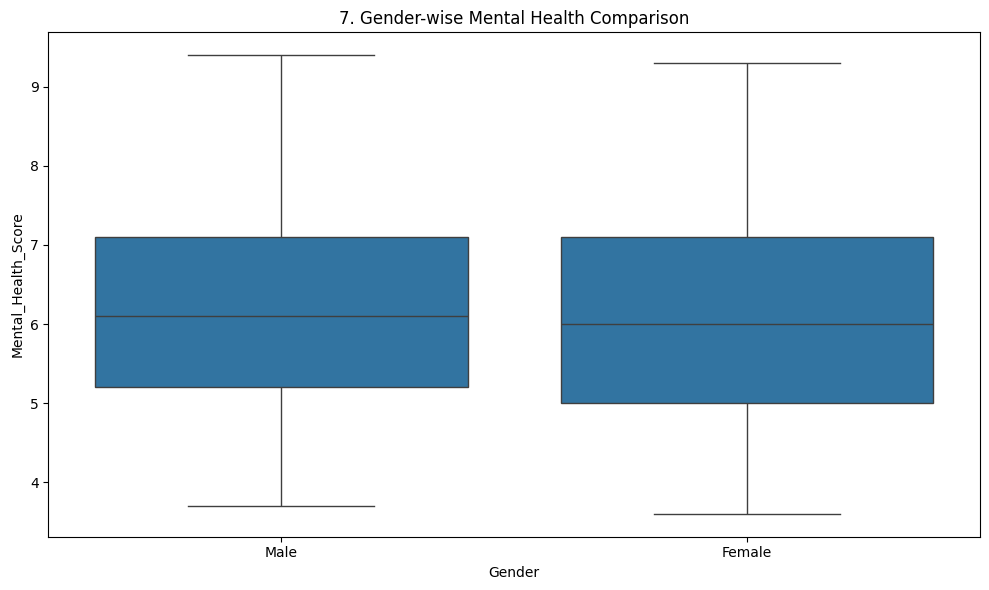

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Gender', y='Mental_Health_Score')
plt.title(f'{plot_no}. Gender-wise Mental Health Comparison')
show_fig()
plot_no += 1

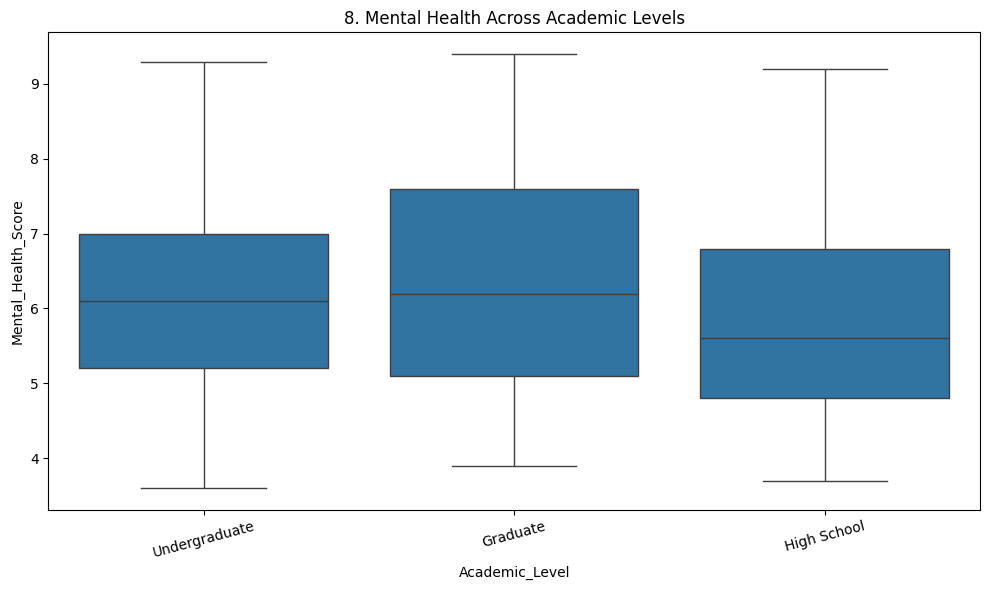

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Academic_Level', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health Across Academic Levels')
plt.xticks(rotation=15)
show_fig()
plot_no += 1

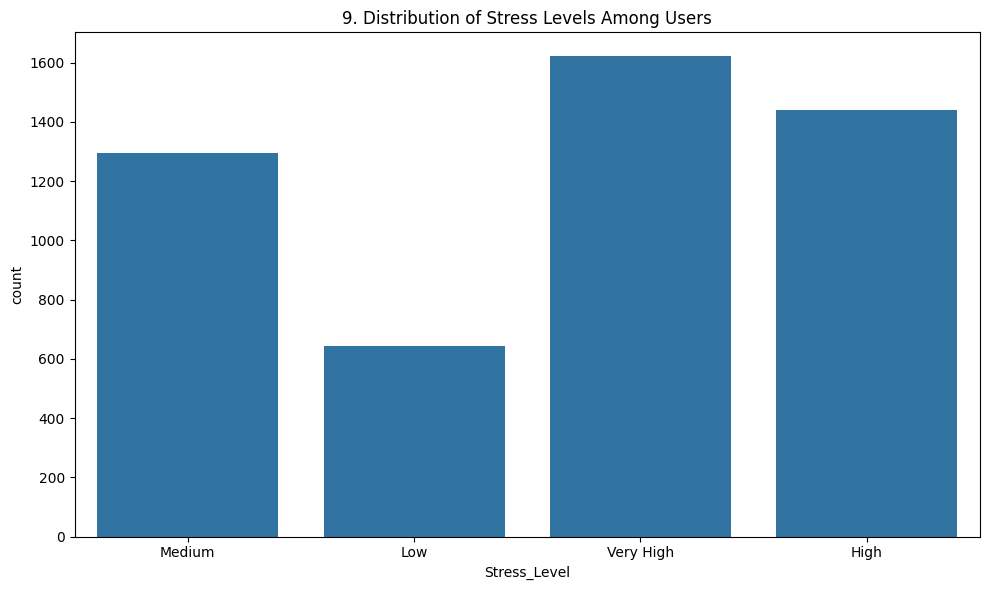

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Stress_Level')
plt.title(f'{plot_no}. Distribution of Stress Levels Among Users')
show_fig()
plot_no += 1

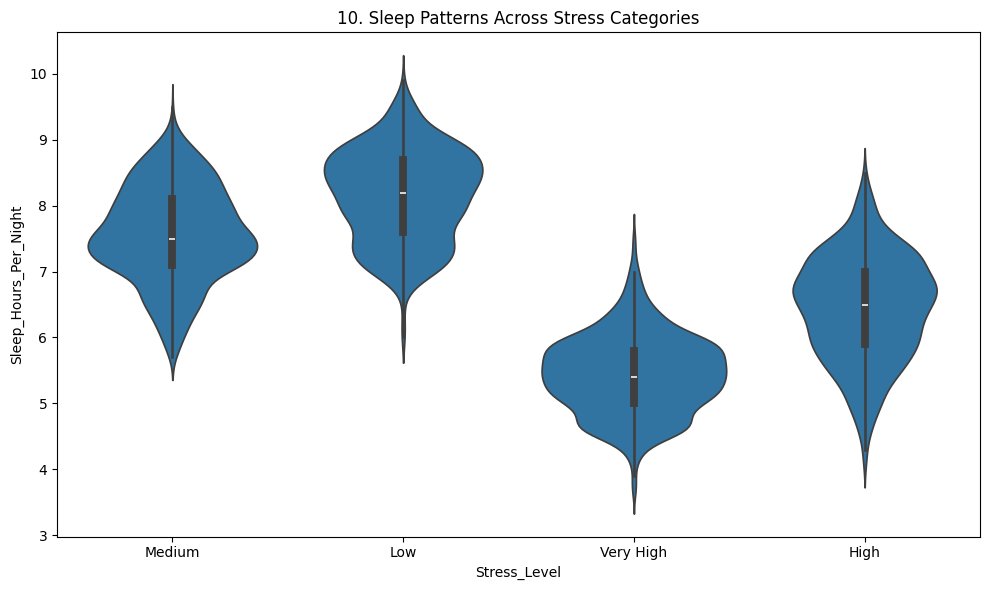

In [22]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Stress_Level', y='Sleep_Hours_Per_Night')
plt.title(f'{plot_no}. Sleep Patterns Across Stress Categories')
show_fig()
plot_no += 1

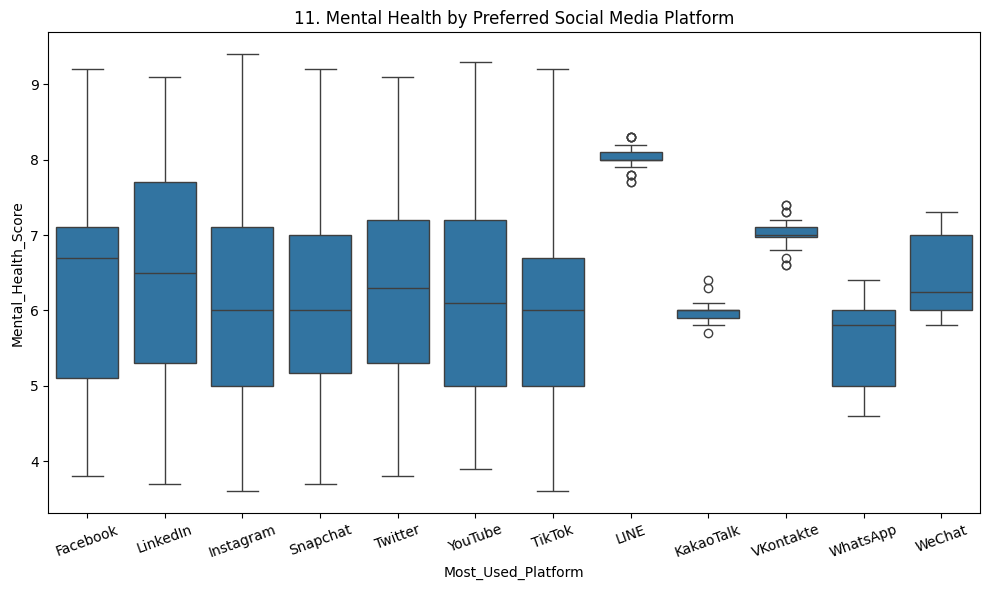

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Most_Used_Platform', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health by Preferred Social Media Platform')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

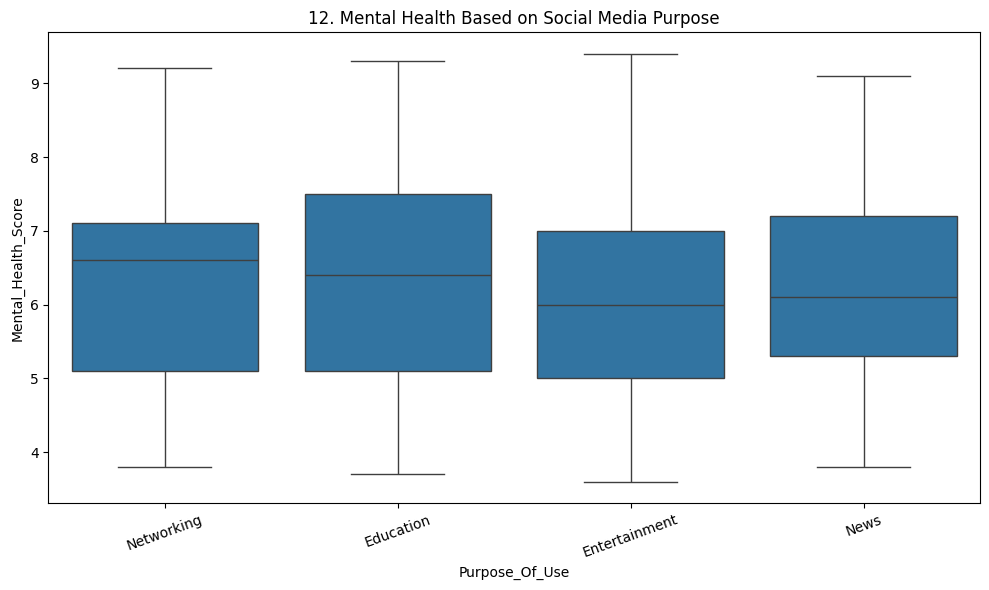

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Purpose_Of_Use', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health Based on Social Media Purpose')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

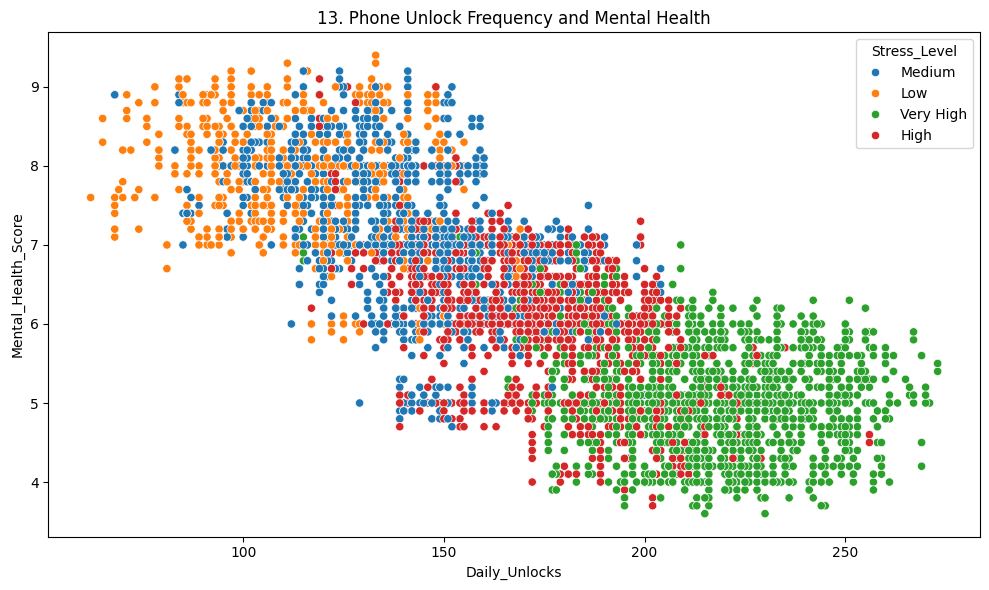

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Daily_Unlocks', y='Mental_Health_Score', hue='Stress_Level')
plt.title(f'{plot_no}. Phone Unlock Frequency and Mental Health')
show_fig()
plot_no += 1

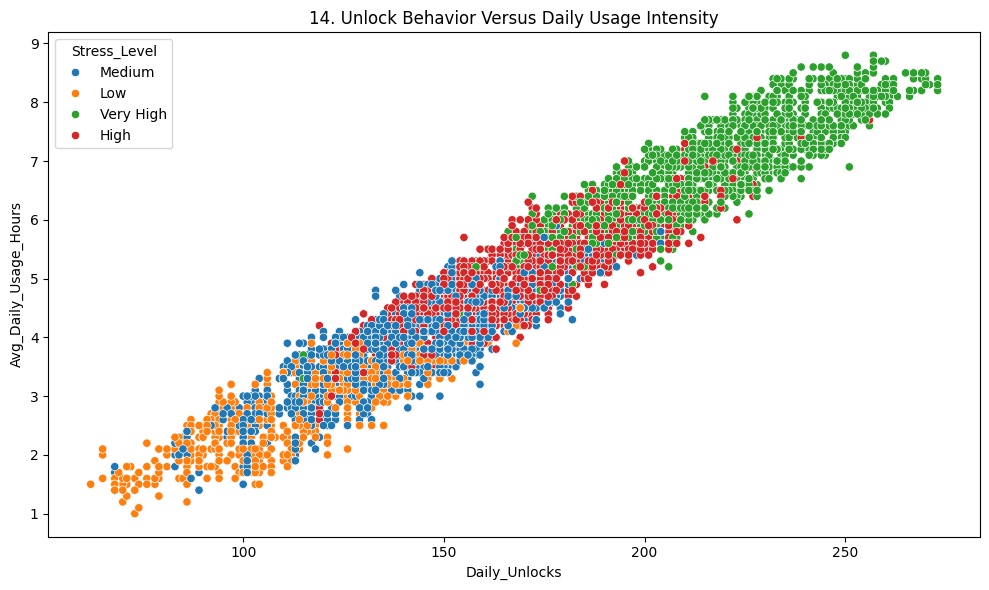

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Daily_Unlocks', y='Avg_Daily_Usage_Hours', hue='Stress_Level')
plt.title(f'{plot_no}. Unlock Behavior Versus Daily Usage Intensity')
show_fig()
plot_no += 1

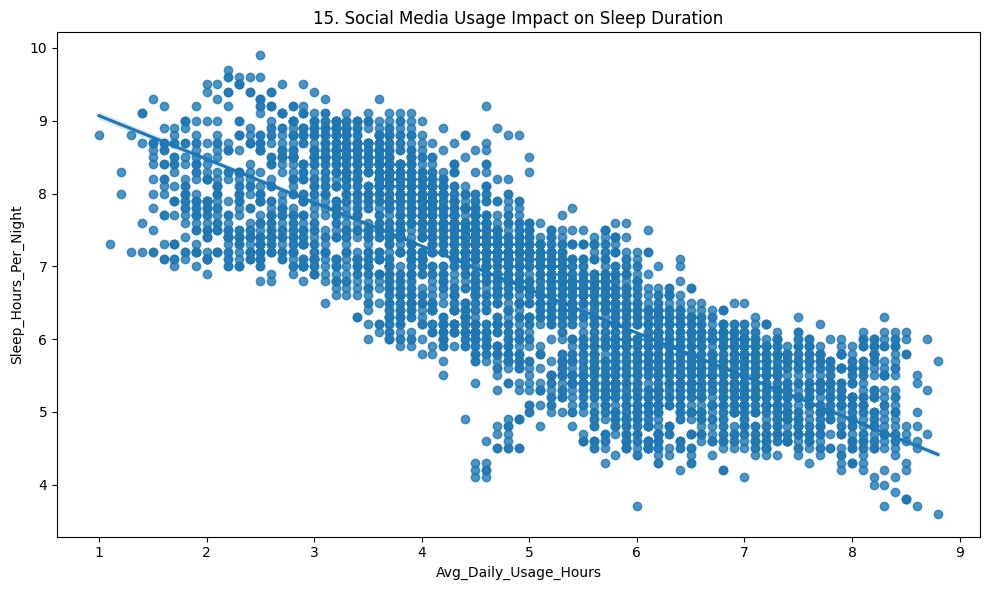

In [27]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night')
plt.title(f'{plot_no}. Social Media Usage Impact on Sleep Duration')
show_fig()
plot_no += 1

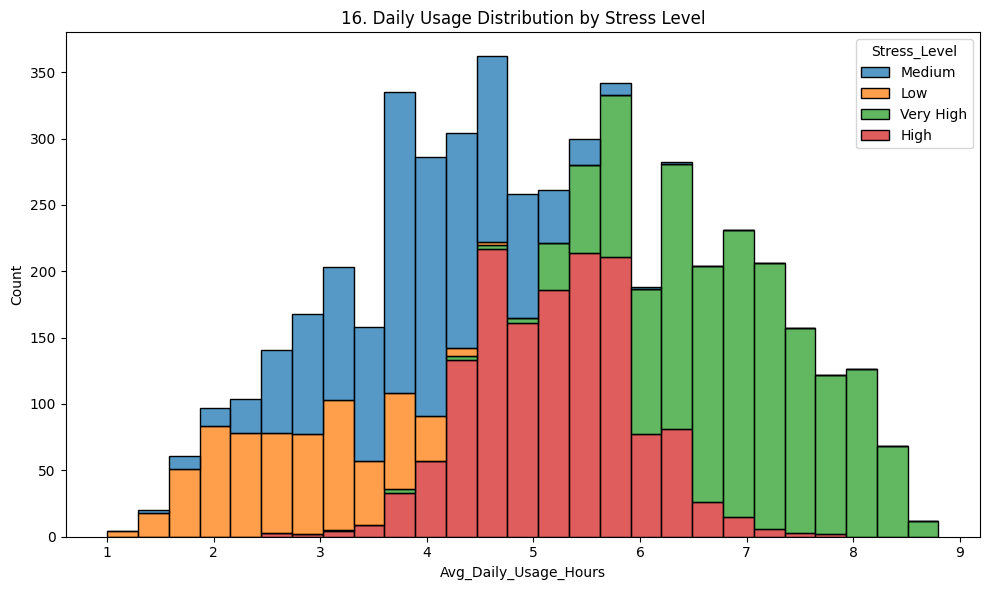

In [28]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Avg_Daily_Usage_Hours', hue='Stress_Level', multiple='stack')
plt.title(f'{plot_no}. Daily Usage Distribution by Stress Level')
show_fig()
plot_no += 1

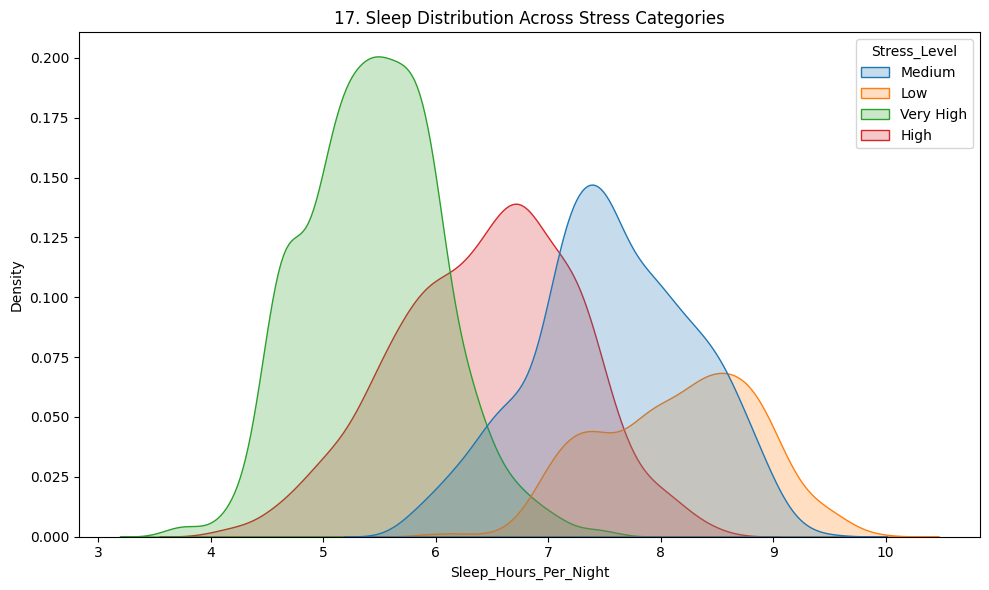

In [29]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Sleep_Hours_Per_Night', hue='Stress_Level', fill=True)
plt.title(f'{plot_no}. Sleep Distribution Across Stress Categories')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

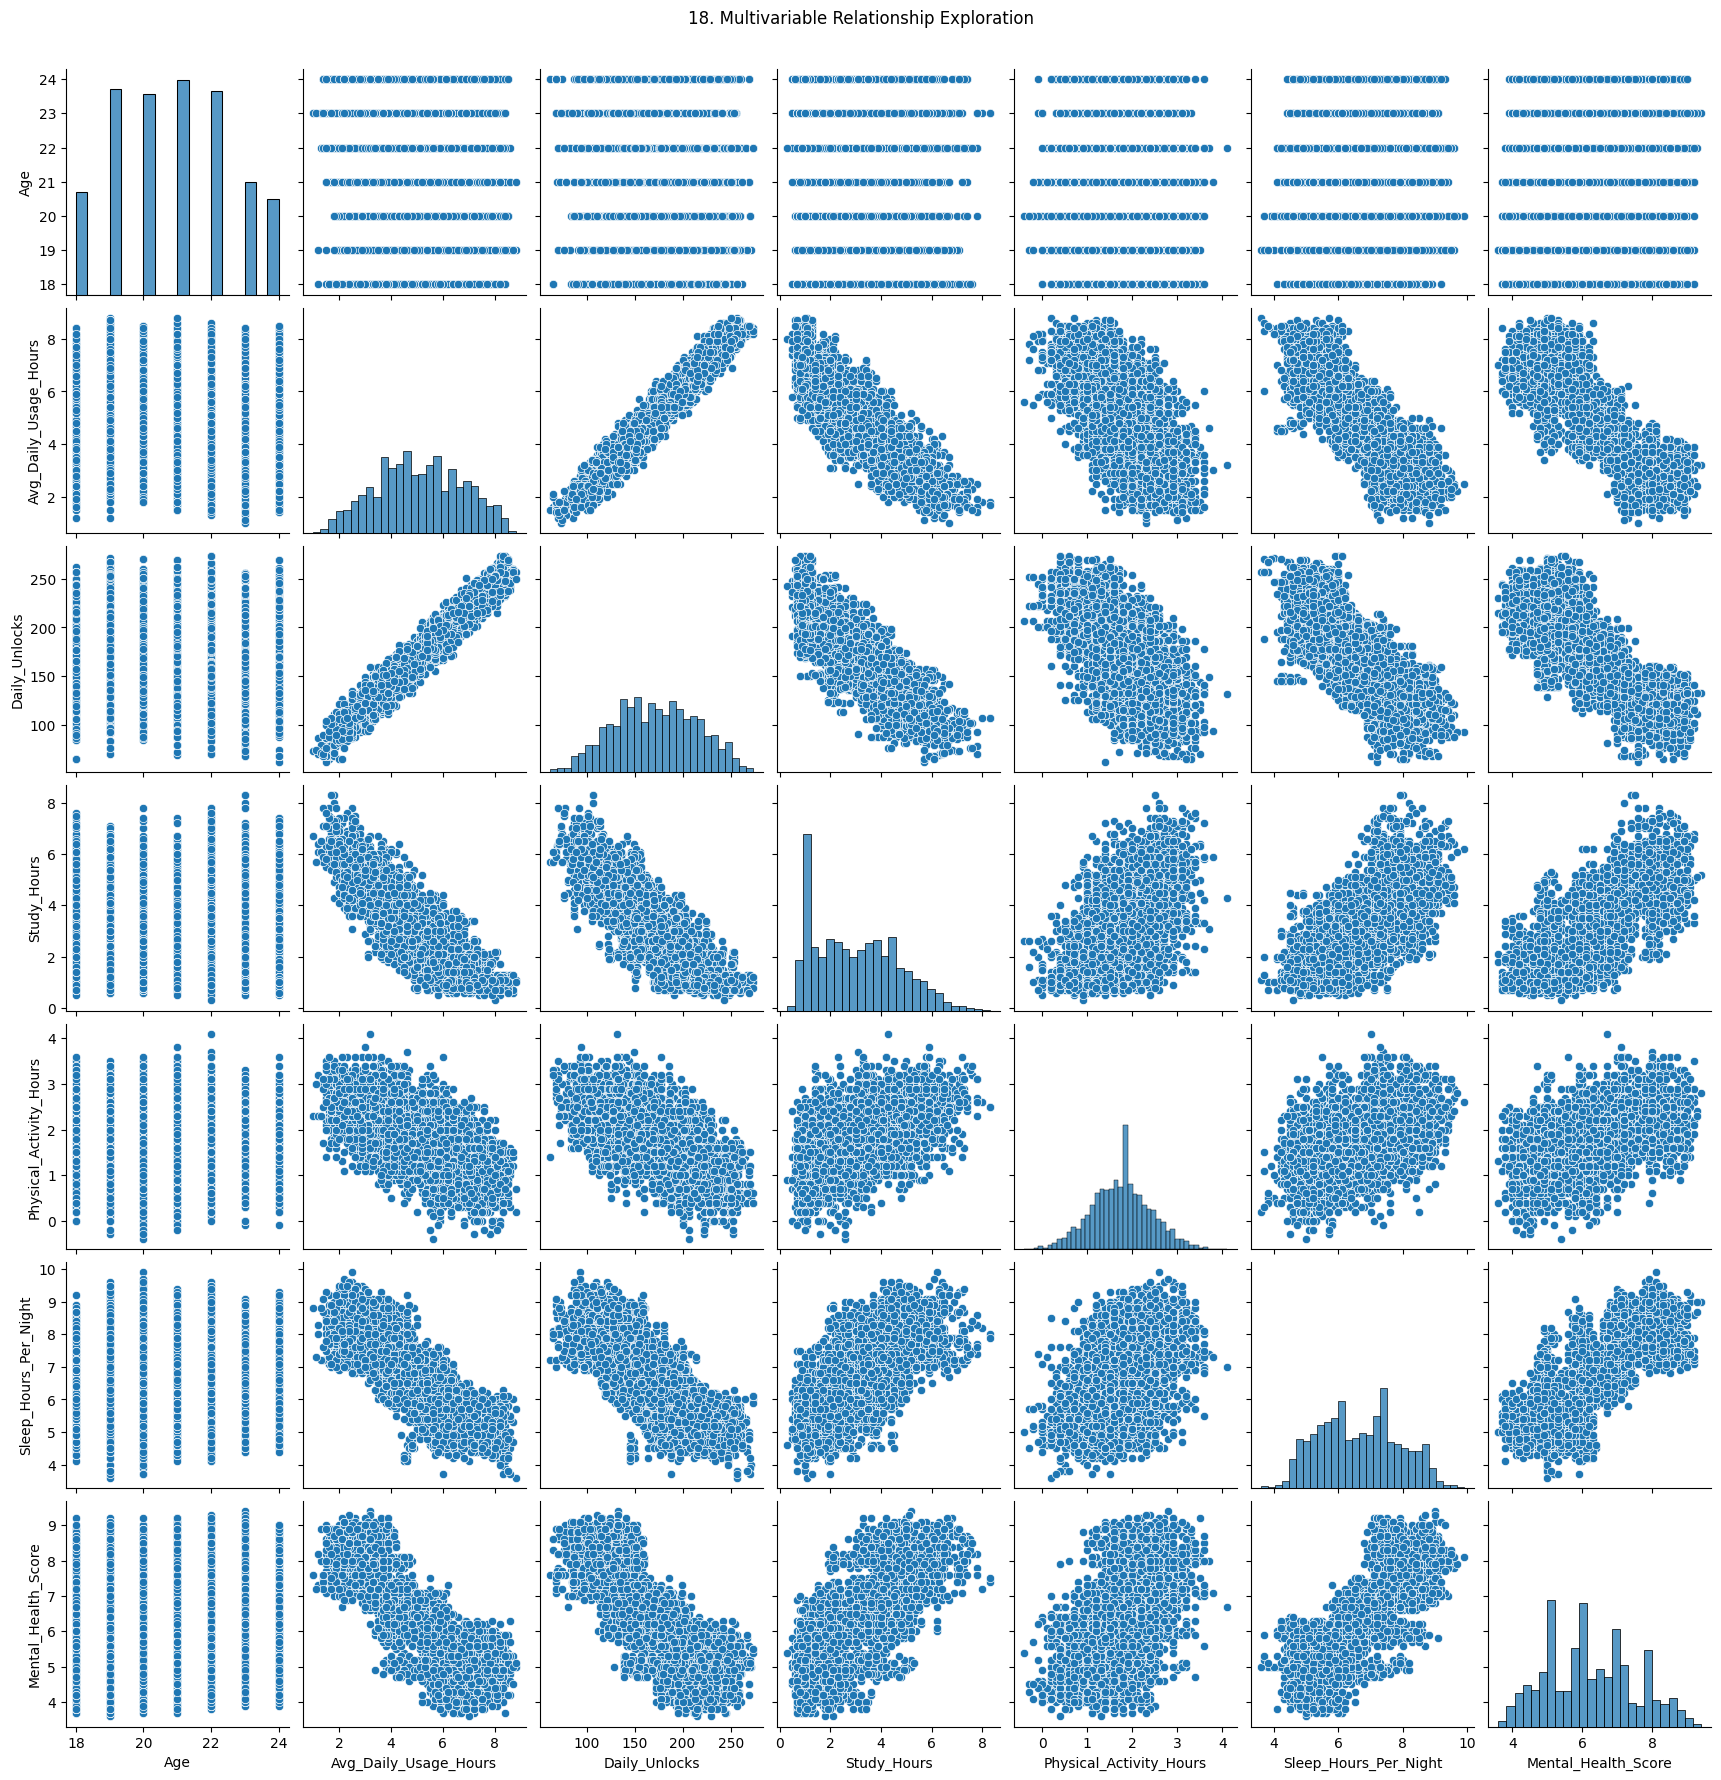

In [30]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Study_Hours','Physical_Activity_Hours','Sleep_Hours_Per_Night','Mental_Health_Score']])
plt.suptitle(f'{plot_no}. Multivariable Relationship Exploration', y=1.02)
plt.show()
plot_no += 1

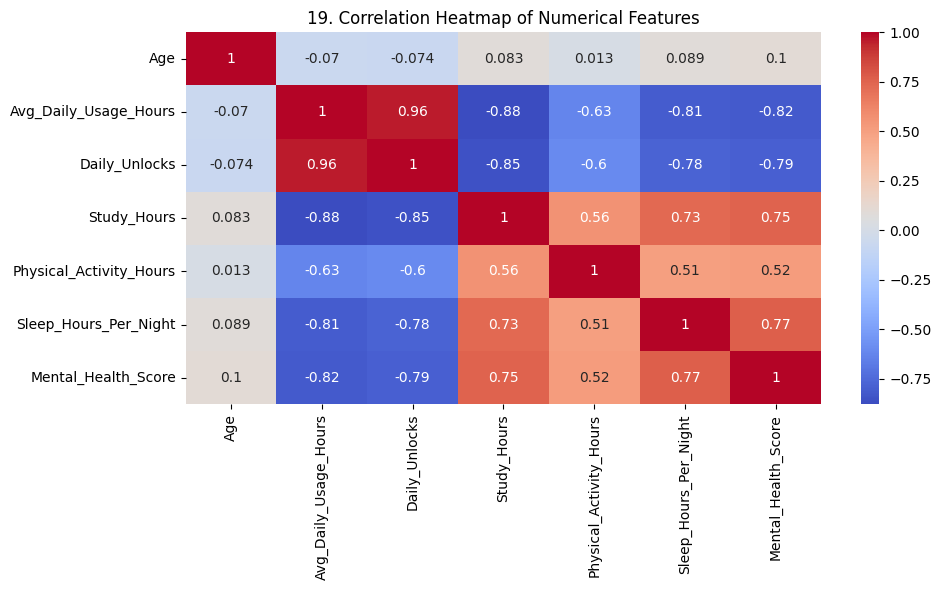

In [31]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Select target column

In [32]:
target_col = 'Mental_Health_Score'

## Split features and target

In [33]:
X = df.drop(columns=[target_col])
y = df[target_col]

## Find numeric and categorical columns

In [34]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

## Numeric preprocessing

In [35]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Categorical preprocessing

In [36]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine preprocessing

In [37]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

## Create model pipeline

In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        random_state=42
    ))
])

## Train test split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Train model

In [40]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict

In [41]:
y_pred = model.predict(X_test)

## Print metrics

In [42]:
print("R2 Accuracy Score:", round(r2_score(y_test, y_pred) * 100, 2), "%")
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

R2 Accuracy Score: 87.36 %
MAE: 0.3601
RMSE: 0.4681


## Actual vs Predicted chart

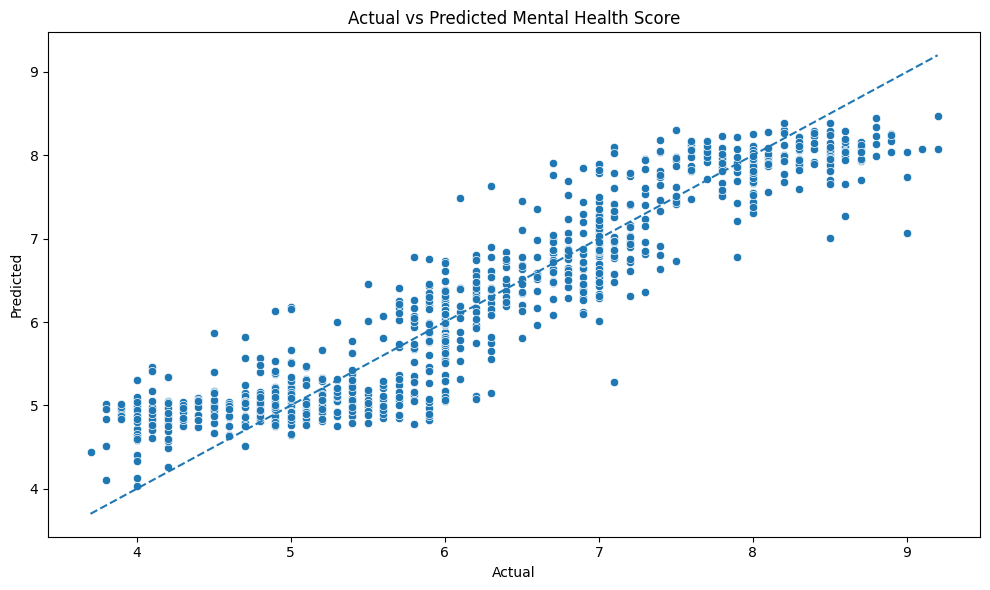

In [43]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Mental Health Score")
plt.tight_layout()
plt.show()